Tutorial original en ultralytics

https://colab.research.google.com/github/ultralytics/ultralytics/blob/main/examples/tutorial.ipynb#scrollTo=bpF9-vS_DAaf


App para anotar/etiquetar imágenes de nuestra propia base de datos:

https://app.roboflow.com/login

In [30]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)


# 1. Predict

YOLOv8 may be used directly in the Command Line Interface (CLI) with a `yolo` command for a variety of tasks and modes and accepts additional arguments, i.e. `imgsz=640`. See a full list of available `yolo` [arguments](https://docs.ultralytics.com/usage/cfg/) and other details in the [YOLOv8 Predict Docs](https://docs.ultralytics.com/modes/train/).

In [31]:
# Run inference on an image with YOLOv8n
!yolo predict model=yolov8n.pt source='https://ultralytics.com/images/zidane.jpg'

Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 9.3ms
Speed: 45.0ms preprocess, 9.3ms inference, 31.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict-12
💡 Learn more at https://docs.ultralytics.com/modes/predict


## 1. Detection

YOLOv8 _detection_ models have no suffix and are the default YOLOv8 models, i.e. `yolov8n.pt` and are pretrained on COCO. See [Detection Docs](https://docs.ultralytics.com/tasks/detect/) for full details.

In [32]:
# Load YOLOv8n, train it on COCO128 for 3 epochs and predict an image with it
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # load a pretrained YOLOv8n detection model
model.train(data='coco128.yaml', epochs=3)  # train the model
model('https://ultralytics.com/images/bus.jpg', save=True)  # predict on an image

Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-7, nbs=64, nms=None, opset=None, optimize=False, optimizer=

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 

## Ejercicio 1: cambiar la imagen de prediccion

Estas celdas dejan evidencia de:

- la prediccion original sobre `zidane.jpg`;
- la prediccion original sobre `bus.jpg` despues del entrenamiento de 3 epocas;
- la prediccion modificada usando la misma imagen propia en CLI y en `model(...)`;
- el reto opcional con `conf=0.7` y con `yolov8s.pt`.


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
from collections import Counter
from pathlib import Path

from IPython.display import Image as ImagenNotebook
from IPython.display import Video, display
from PIL import Image as PILImage
import matplotlib.pyplot as plt
from ultralytics import YOLO

ORIGINAL_ZIDANE = "https://ultralytics.com/images/zidane.jpg"
ORIGINAL_BUS = "https://ultralytics.com/images/bus.jpg"

MI_IMAGEN = "/content/drive/MyDrive/Msc_InteligenciaAritifical/06. Visión Computacional/Notebooks/zoologico.jpg"

print("Imagen original CLI:", ORIGINAL_ZIDANE)
print("Imagen original Python:", ORIGINAL_BUS)
print("Imagen propia para ambas predicciones modificadas:", MI_IMAGEN)

Imagen original CLI: https://ultralytics.com/images/zidane.jpg
Imagen original Python: https://ultralytics.com/images/bus.jpg
Imagen propia para ambas predicciones modificadas: /content/drive/MyDrive/Msc_InteligenciaAritifical/06. Visión Computacional/Notebooks/zoologico.jpg


In [35]:
def mostrar_fuente(source, titulo="Imagen de entrada"):
    print("\n" + titulo)
    print(source)

    source_text = str(source)
    if source_text.startswith(("http://", "https://")):
        display(ImagenNotebook(url=source_text, width=720))
        return

    path = Path(source_text)
    if not path.exists():
        print("No se encontro el archivo. Revisa la ruta antes de predecir.")
        return

    display(ImagenNotebook(filename=str(path), width=720))


def imagenes_de_carpeta(carpeta):
    carpeta = Path(carpeta)
    if not carpeta.exists():
        return []
    extensiones = {".jpg", ".jpeg", ".png"}
    return sorted(p for p in carpeta.rglob("*") if p.suffix.lower() in extensiones)


def mostrar_imagenes_guardadas(carpeta, titulo="Imagenes guardadas por YOLO", max_imagenes=8):
    print("\n" + titulo)
    carpeta = Path(carpeta)
    print("Carpeta:", carpeta)

    imagenes = imagenes_de_carpeta(carpeta)
    print("Imagenes encontradas:", len(imagenes))

    if not imagenes:
        print("No hay imagenes para mostrar todavia. Ejecuta primero la celda de prediccion.")
        return

    for imagen in imagenes[:max_imagenes]:
        print("Mostrando:", imagen)
        display(ImagenNotebook(filename=str(imagen), width=720))


def resumir_resultados_yolo(results, etiqueta):
    print("\nResumen de detecciones:", etiqueta)
    total_boxes = 0

    for img_idx, result in enumerate(results):
        boxes = result.boxes
        if boxes is None or len(boxes) == 0:
            print(f"Imagen {img_idx}: 0 cajas")
            continue

        clases = [result.names[int(cls)] for cls in boxes.cls]
        confs = [float(conf) for conf in boxes.conf]
        total_boxes += len(clases)

        print(f"Imagen {img_idx}: {len(clases)} cajas")
        print("Conteo por clase:", dict(Counter(clases)))
        print("Detalle clase/confianza:")
        for clase, conf in zip(clases, confs):
            print(f"  - {clase}: {conf:.3f}")

        if getattr(result, "save_dir", None):
            print("Carpeta guardada:", result.save_dir)

    print("Total de cajas:", total_boxes)


def mostrar_comparacion_carpetas(carpeta_a, carpeta_b, titulo_a, titulo_b):
    imgs_a = imagenes_de_carpeta(carpeta_a)
    imgs_b = imagenes_de_carpeta(carpeta_b)

    if not imgs_a or not imgs_b:
        print("Falta alguna imagen para comparar.")
        print(titulo_a, "->", len(imgs_a), "imagenes")
        print(titulo_b, "->", len(imgs_b), "imagenes")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, image_path, title in zip(axes, [imgs_a[0], imgs_b[0]], [titulo_a, titulo_b]):
        ax.imshow(PILImage.open(image_path))
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


Entrada original para la prediccion CLI: zidane.jpg
https://ultralytics.com/images/zidane.jpg



Prediccion original CLI con yolov8n.pt sobre zidane.jpg
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 6.3ms
Speed: 33.4ms preprocess, 6.3ms inference, 17.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict_zidane-4
💡 Learn more at https://docs.ultralytics.com/modes/predict

Salida con cajas: prediccion original CLI sobre zidane.jpg
Carpeta: runs/detect/predict_zidane
Imagenes encontradas: 1
Mostrando: runs/detect/predict_zidane/zidane.jpg


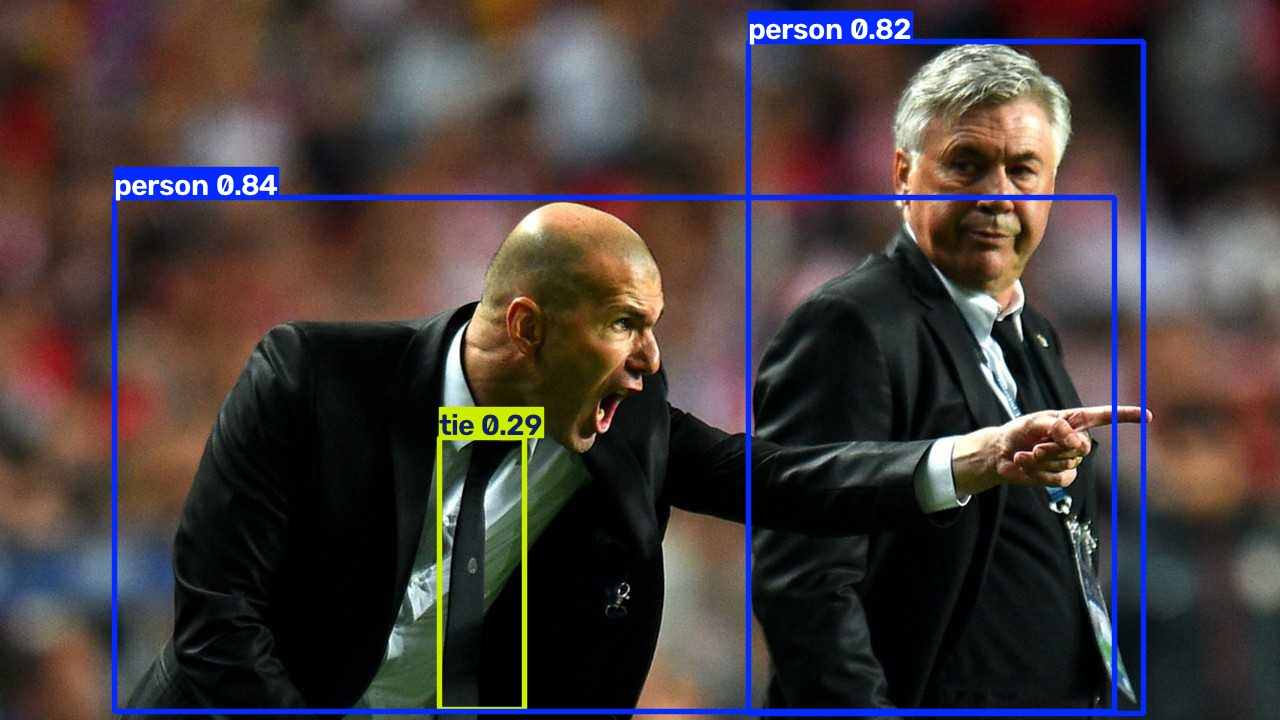

In [36]:
mostrar_fuente(ORIGINAL_ZIDANE, "Entrada original para la prediccion CLI: zidane.jpg")

print("\nPrediccion original CLI con yolov8n.pt sobre zidane.jpg")
!yolo predict model=yolov8n.pt source="{ORIGINAL_ZIDANE}" save=True name="predict_zidane"

# La ruta por defecto de YOLO es runs/detect/name
mostrar_imagenes_guardadas(
    "runs/detect/predict_zidane",
    "Salida con cajas: prediccion original CLI sobre zidane.jpg",
)


Entrada original para la prediccion Python: bus.jpg
https://ultralytics.com/images/bus.jpg



Prediccion original Python model(...) sobre bus.jpg

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 6.3ms
Speed: 1.8ms preprocess, 6.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict_bus-4

Resumen de detecciones: Python model(...) original sobre bus.jpg
Imagen 0: 6 cajas
Conteo por clase: {'bus': 1, 'person': 4, 'stop sign': 1}
Detalle clase/confianza:
  - bus: 0.873
  - person: 0.866
  - person: 0.853
  - person: 0.825
  - person: 0.261
  - stop sign: 0.255
Carpeta guardada: /content/runs/detect/predict_bus-4
Total de cajas: 6

Salida con cajas: prediccion original Python sobre bus.jpg
Carpeta: runs/detect/predict_bus
Imagenes encontradas: 1
Mostrando: runs/detect/predict_bus/bus.jpg


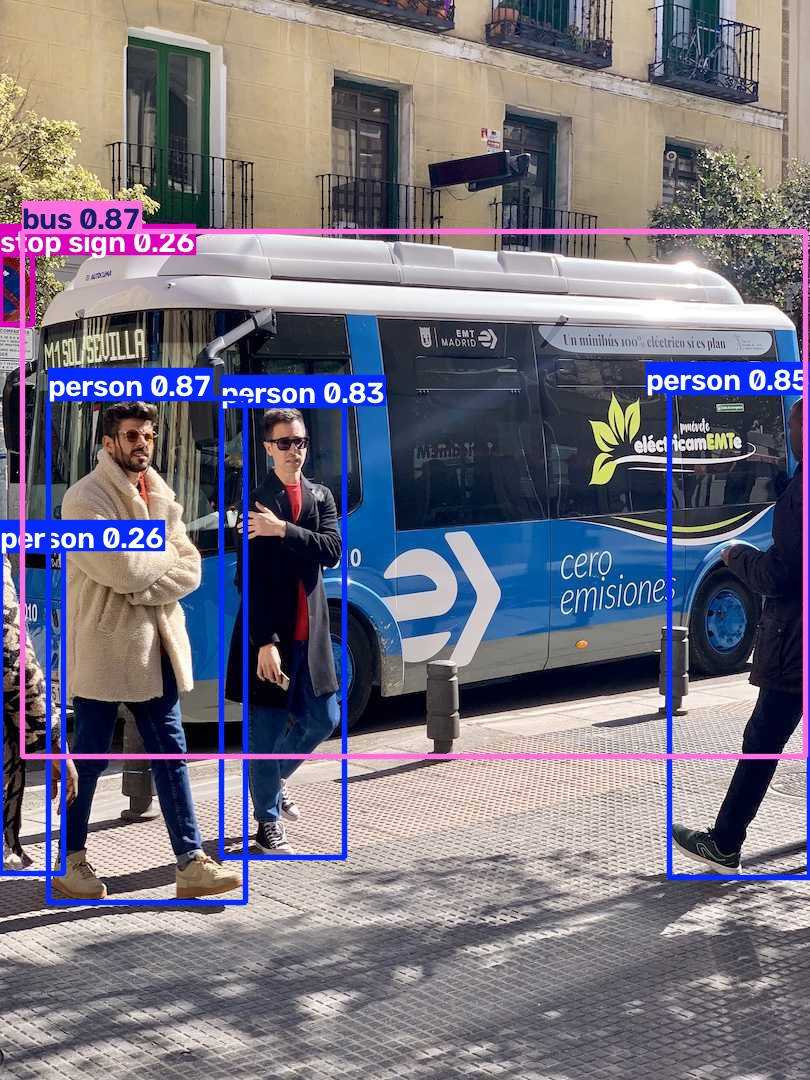

In [37]:
mostrar_fuente(ORIGINAL_BUS, "Entrada original para la prediccion Python: bus.jpg")

modelo_yolov8n_entrenado = YOLO("yolov8n.pt")

print("\nPrediccion original Python model(...) sobre bus.jpg")
resultados_bus_original = modelo_yolov8n_entrenado(
    ORIGINAL_BUS,
    save=True,
    name="predict_bus"
)

resumir_resultados_yolo(resultados_bus_original, "Python model(...) original sobre bus.jpg")
mostrar_imagenes_guardadas(
    "runs/detect/predict_bus",
    "Salida con cajas: prediccion original Python sobre bus.jpg",
)


Imagen propia usada en las dos predicciones modificadas
/content/drive/MyDrive/Msc_InteligenciaAritifical/06. Visión Computacional/Notebooks/zoologico.jpg


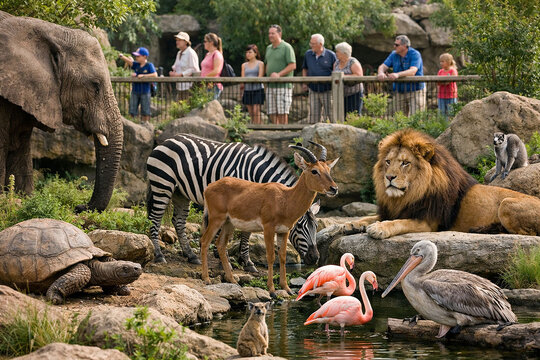


Prediccion modificada CLI con yolov8n.pt sobre la imagen propia
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/drive/MyDrive/Msc_InteligenciaAritifical/06. Visión Computacional/Notebooks/zoologico.jpg: 448x640 9 persons, 4 birds, 1 elephant, 1 bear, 1 zebra, 6.5ms
Speed: 45.8ms preprocess, 6.5ms inference, 17.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict_mi_cli
💡 Learn more at https://docs.ultralytics.com/modes/predict

Salida con cajas: prediccion modificada CLI sobre imagen propia
Carpeta: runs/detect/predict_mi_cli
Imagenes encontradas: 1
Mostrando: runs/detect/predict_mi_cli/zoologico.jpg


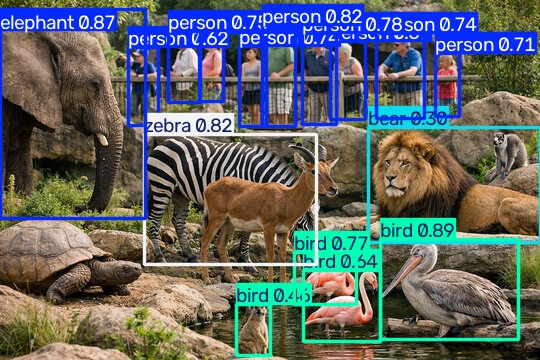

In [38]:
mostrar_fuente(MI_IMAGEN, "Imagen propia usada en las dos predicciones modificadas")

print("\nPrediccion modificada CLI con yolov8n.pt sobre la imagen propia")
!yolo predict model=yolov8n.pt source="{MI_IMAGEN}" save=True name="predict_mi_cli" exist_ok=True

mostrar_imagenes_guardadas(
    "runs/detect/predict_mi_cli",
    "Salida con cajas: prediccion modificada CLI sobre imagen propia",
)

Prediccion modificada Python model(...) con la misma imagen propia: /content/drive/MyDrive/Msc_InteligenciaAritifical/06. Visión Computacional/Notebooks/zoologico.jpg

image 1/1 /content/drive/MyDrive/Msc_InteligenciaAritifical/06. Visión Computacional/Notebooks/zoologico.jpg: 448x640 9 persons, 4 birds, 1 elephant, 1 bear, 1 zebra, 8.1ms
Speed: 2.5ms preprocess, 8.1ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict_mi_python-4

Resumen de detecciones: Python model(...) sobre imagen propia
Imagen 0: 16 cajas
Conteo por clase: {'bird': 4, 'elephant': 1, 'zebra': 1, 'person': 9, 'bear': 1}
Detalle clase/confianza:
  - bird: 0.890
  - elephant: 0.870
  - zebra: 0.822
  - person: 0.817
  - person: 0.781
  - bird: 0.766
  - person: 0.749
  - person: 0.739
  - person: 0.737
  - person: 0.711
  - person: 0.675
  - bird: 0.640
  - person: 0.615
  - person: 0.564
  - bird: 0.460
  - bear: 0.297
Carpeta guardada: /content/runs/dete

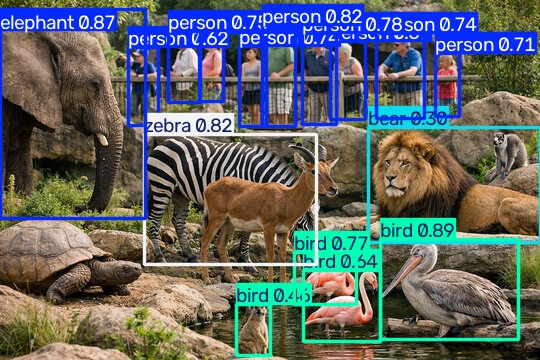

In [39]:
print("Prediccion modificada Python model(...) con la misma imagen propia:", MI_IMAGEN)

resultados_mi_imagen_python = modelo_yolov8n_entrenado(
    MI_IMAGEN,
    save=True,
    name="predict_mi_python"
)

resumir_resultados_yolo(resultados_mi_imagen_python, "Python model(...) sobre imagen propia")
mostrar_imagenes_guardadas(
    "runs/detect/predict_mi_python",
    "Salida con cajas: prediccion modificada Python sobre imagen propia",
)

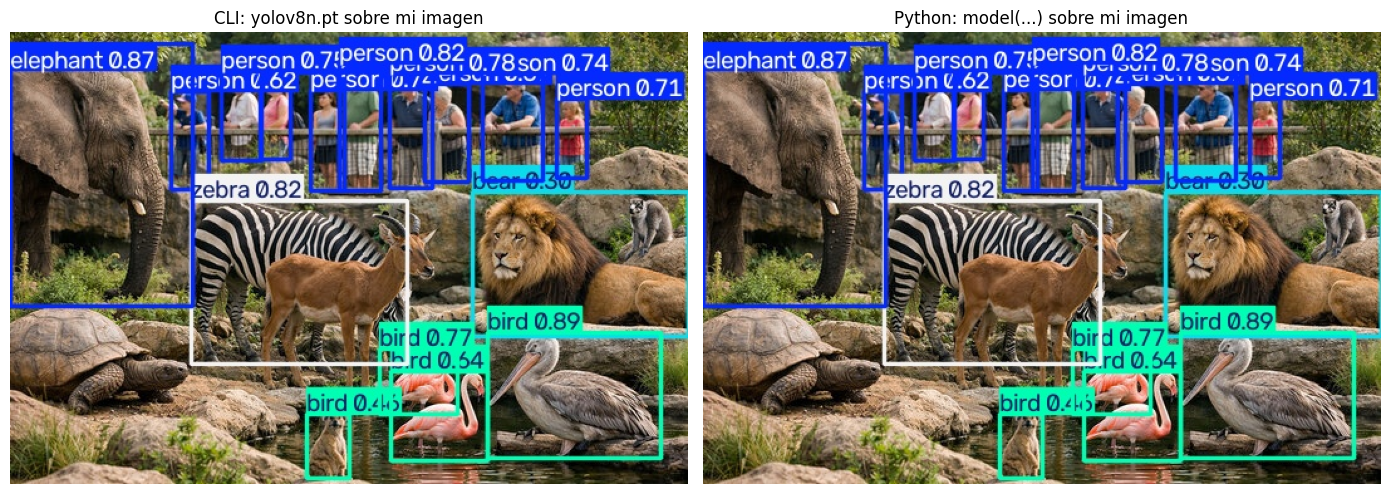

In [40]:
mostrar_comparacion_carpetas(
    "runs/detect/predict_mi_cli",
    "runs/detect/predict_mi_python",
    "CLI: yolov8n.pt sobre mi imagen",
    "Python: model(...) sobre mi imagen",
)

## Reto opcional
Umbral de confianza a `conf=0.7`.

Reto opcional: yolov8n.pt con umbral mas estricto conf=0.7
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/drive/MyDrive/Msc_InteligenciaAritifical/06. Visión Computacional/Notebooks/zoologico.jpg: 448x640 6 persons, 2 birds, 1 elephant, 1 zebra, 6.5ms
Speed: 35.8ms preprocess, 6.5ms inference, 17.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/mi_imagen_conf_07
💡 Learn more at https://docs.ultralytics.com/modes/predict

Salida con cajas: yolov8n.pt, conf=0.7
Carpeta: runs/detect/mi_imagen_conf_07
Imagenes encontradas: 1
Mostrando: runs/detect/mi_imagen_conf_07/zoologico.jpg


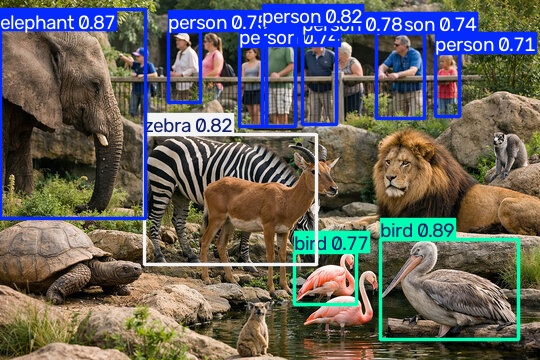

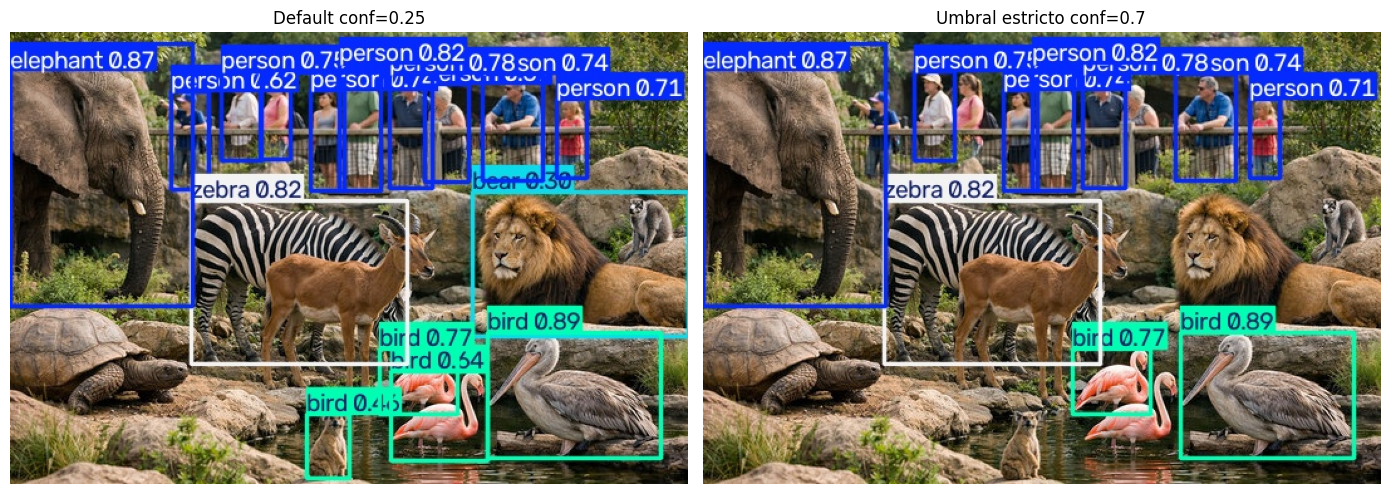

In [41]:
print("Reto opcional: yolov8n.pt con umbral mas estricto conf=0.7")
!yolo predict model=yolov8n.pt source="{MI_IMAGEN}" conf=0.7 name="mi_imagen_conf_07" exist_ok=True

mostrar_imagenes_guardadas(
    "runs/detect/mi_imagen_conf_07",
    "Salida con cajas: yolov8n.pt, conf=0.7",
)

mostrar_comparacion_carpetas(
    "runs/detect/predict_mi_cli",
    "runs/detect/mi_imagen_conf_07",
    "Default conf=0.25",
    "Umbral estricto conf=0.7",
)

Reto opcional: cambiar solo el modelo de prediccion CLI a yolov8s.pt
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs

image 1/1 /content/drive/MyDrive/Msc_InteligenciaAritifical/06. Visión Computacional/Notebooks/zoologico.jpg: 448x640 10 persons, 6 birds, 3 elephants, 2 zebras, 12.9ms
Speed: 34.0ms preprocess, 12.9ms inference, 23.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/mi_imagen_yolov8s
💡 Learn more at https://docs.ultralytics.com/modes/predict

Salida con cajas: yolov8s.pt sobre imagen propia
Carpeta: runs/detect/mi_imagen_yolov8s
Imagenes encontradas: 1
Mostrando: runs/detect/mi_imagen_yolov8s/zoologico.jpg


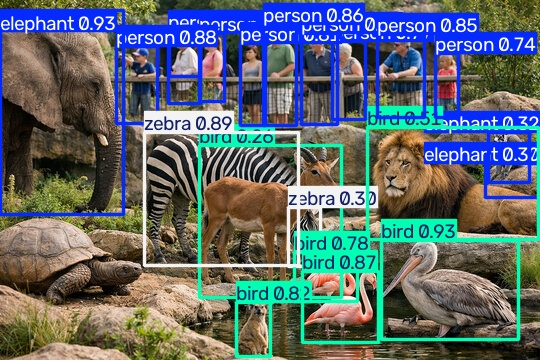

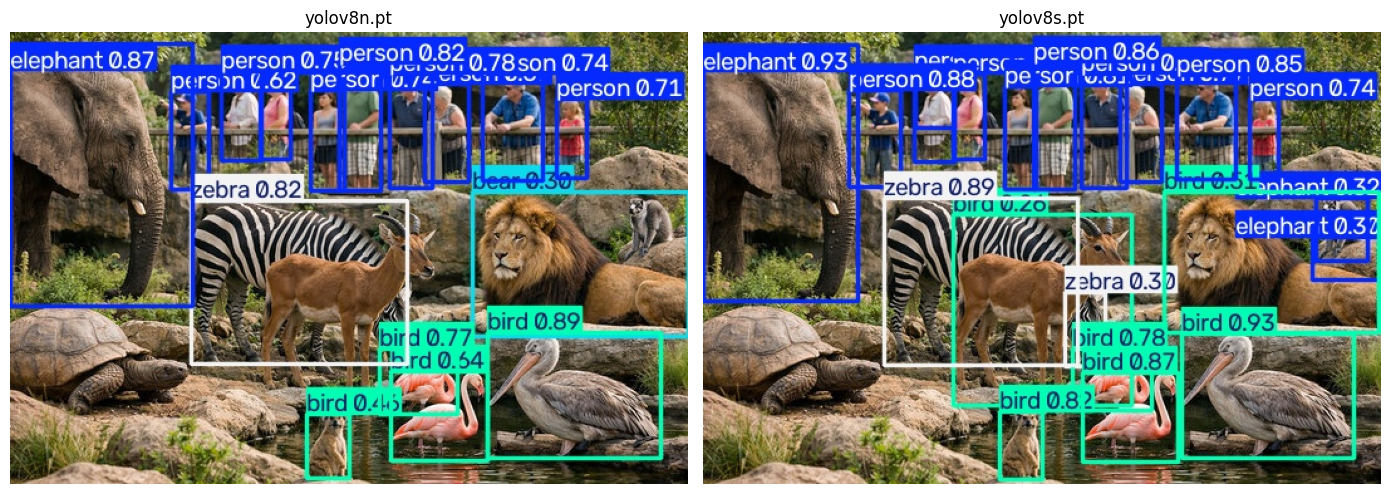

In [42]:
print("Reto opcional: cambiar solo el modelo de prediccion CLI a yolov8s.pt")
!yolo predict model=yolov8s.pt source="{MI_IMAGEN}" name="mi_imagen_yolov8s" exist_ok=True

mostrar_imagenes_guardadas(
    "runs/detect/mi_imagen_yolov8s",
    "Salida con cajas: yolov8s.pt sobre imagen propia",
)

mostrar_comparacion_carpetas(
    "runs/detect/predict_mi_cli",
    "runs/detect/mi_imagen_yolov8s",
    "yolov8n.pt",
    "yolov8s.pt",
)